# Udemy Courses Dataset: Data Understanding

## 1. Project Introduction

This notebook presents an exploratory data analysis (EDA) of the Udemy Courses dataset. The purpose is to understand the structure, quality, and key characteristics of the data before building machine learning recommendation algorithms.

For a recommender systems project, data understanding is an important first step because it helps identify which features can describe course content, popularity, pricing, and learner interest. These insights will guide the selection of an appropriate recommendation approach in later notebooks.

## 2. Import Libraries

Only the libraries needed for basic data analysis and visualization are imported.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

## 3. Load Dataset

The dataset is loaded from the `data/raw` folder. The first few rows are displayed to get an initial view of the available course information.

In [2]:
data_path = Path("data/raw/udemy_courses.csv")
if not data_path.exists():
    data_path = Path("../data/raw/udemy_courses.csv")

df = pd.read_csv(data_path)
df.head()

,course_id,course_title,url,is_paid,price,num_subscribers,num_reviews,num_lectures,level,content_duration,published_timestamp,subject
0,1070968,Ultimate Investment Banking Course,https://www.udemy.com/ultimate-investment-bank...,True,200,2147,23,51,All Levels,1.5,2017-01-18T20:58:58Z,Business Finance
1,1113822,Complete GST Course & Certification - Grow You...,https://www.udemy.com/goods-and-services-tax/,True,75,2792,923,274,All Levels,39.0,2017-03-09T16:34:20Z,Business Finance
2,1006314,Financial Modeling for Business Analysts and C...,https://www.udemy.com/financial-modeling-for-b...,True,45,2174,74,51,Intermediate Level,2.5,2016-12-19T19:26:30Z,Business Finance
3,1210588,Beginner to Pro - Financial Analysis in Excel ...,https://www.udemy.com/complete-excel-finance-c...,True,95,2451,11,36,All Levels,3.0,2017-05-30T20:07:24Z,Business Finance
4,1011058,How To Maximize Your Profits Trading Options,https://www.udemy.com/how-to-maximize-your-pro...,True,200,1276,45,26,Intermediate Level,2.0,2016-12-13T14:57:18Z,Business Finance


## 4. Dataset Shape

The shape of the dataset shows how many course records and features are available.

In [3]:
rows, columns = df.shape
print(f"Number of rows: {rows}")
print(f"Number of columns: {columns}")

Number of rows: 3678
Number of columns: 12


The dataset contains 3,678 rows and 12 columns. It is suitable for a university-level recommender systems project because it has enough course metadata to support content-based recommendations, while still being small enough to inspect manually.


## 5. Column Understanding

The column names and data types help identify which features may be useful for recommendation.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3678 entries, 0 to 3677
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   course_id            3678 non-null   int64  
 1   course_title         3678 non-null   object 
 2   url                  3678 non-null   object 
 3   is_paid              3678 non-null   bool   
 4   price                3678 non-null   int64  
 5   num_subscribers      3678 non-null   int64  
 6   num_reviews          3678 non-null   int64  
 7   num_lectures         3678 non-null   int64  
 8   level                3678 non-null   object 
 9   content_duration     3678 non-null   float64
 10  published_timestamp  3678 non-null   object 
 11  subject              3678 non-null   object 
dtypes: bool(1), float64(1), int64(5), object(5)
memory usage: 319.8+ KB


In [5]:
df.dtypes

course_id                int64
course_title            object
url                     object
is_paid                   bool
price                    int64
num_subscribers          int64
num_reviews              int64
num_lectures             int64
level                   object
content_duration       float64
published_timestamp     object
subject                 object
dtype: object

Important columns for recommendation systems include:

- `course_title`: useful text information that can represent course content and topics.
- `subject`: identifies the main category of each course and can help recommend courses from similar domains.
- `level`: describes the difficulty level, which is important for matching courses to learner experience.
- `price` and `is_paid`: can support recommendations based on budget or preference for free/paid courses.
- `num_subscribers` and `num_reviews`: indicate popularity and engagement, which may help rank or filter recommendations.
- `num_lectures` and `content_duration`: describe course depth and workload.

The dataset does not contain user IDs, individual ratings, or user-course interaction histories. This limits the project to course-metadata and popularity-based recommendation methods unless additional interaction data is added.


A small consistency check is useful here because numeric fields should not contain negative values, and free/paid labels should agree with the price column.


In [6]:
quality_checks = pd.Series({
    "free_courses_with_price": ((df["is_paid"] == False) & (df["price"] > 0)).sum(),
    "paid_courses_with_zero_price": ((df["is_paid"] == True) & (df["price"] == 0)).sum(),
    "courses_with_zero_subscribers": (df["num_subscribers"] == 0).sum(),
    "courses_with_zero_lectures": (df["num_lectures"] == 0).sum(),
    "courses_with_zero_duration": (df["content_duration"] == 0).sum(),
    "negative_numeric_values": (df[["price", "num_subscribers", "num_reviews", "num_lectures", "content_duration"]] < 0).sum().sum()
})

quality_checks


free_courses_with_price           0
paid_courses_with_zero_price      0
courses_with_zero_subscribers    70
courses_with_zero_lectures        1
courses_with_zero_duration        1
negative_numeric_values           0
dtype: int64

The quality checks do not show price/free-label conflicts or negative numeric values. The zero-subscriber courses are reasonable for a marketplace dataset, while the single zero-lecture and zero-duration record should be handled during preprocessing.


## 6. Missing Values

Missing values are checked to understand whether any preprocessing is needed before modeling.

In [7]:
missing_values = df.isnull().sum()
missing_values

course_id              0
course_title           0
url                    0
is_paid                0
price                  0
num_subscribers        0
num_reviews            0
num_lectures           0
level                  0
content_duration       0
published_timestamp    0
subject                0
dtype: int64

The dataset has no missing values in the current CSV. No imputation is needed at this stage, but this check should remain in the notebook so preprocessing can catch missing values if the source file changes.


## 7. Duplicate Rows

Duplicate rows are checked because repeated courses can distort analysis and recommendations.

In [8]:
duplicate_rows = df.duplicated().sum()
duplicate_course_ids = df.duplicated(subset="course_id").sum()

print(f"Number of duplicate rows: {duplicate_rows}")
print(f"Number of duplicate course IDs: {duplicate_course_ids}")


Number of duplicate rows: 6
Number of duplicate course IDs: 6


The current CSV contains 6 duplicate rows, and these are also duplicate `course_id` values. These records should be removed during preprocessing so the same course is not counted or recommended more than once.


## 8. Visualizations

The following visualizations focus on course categories, subscriber distribution, and course levels.

### Number of Courses per Subject/Category

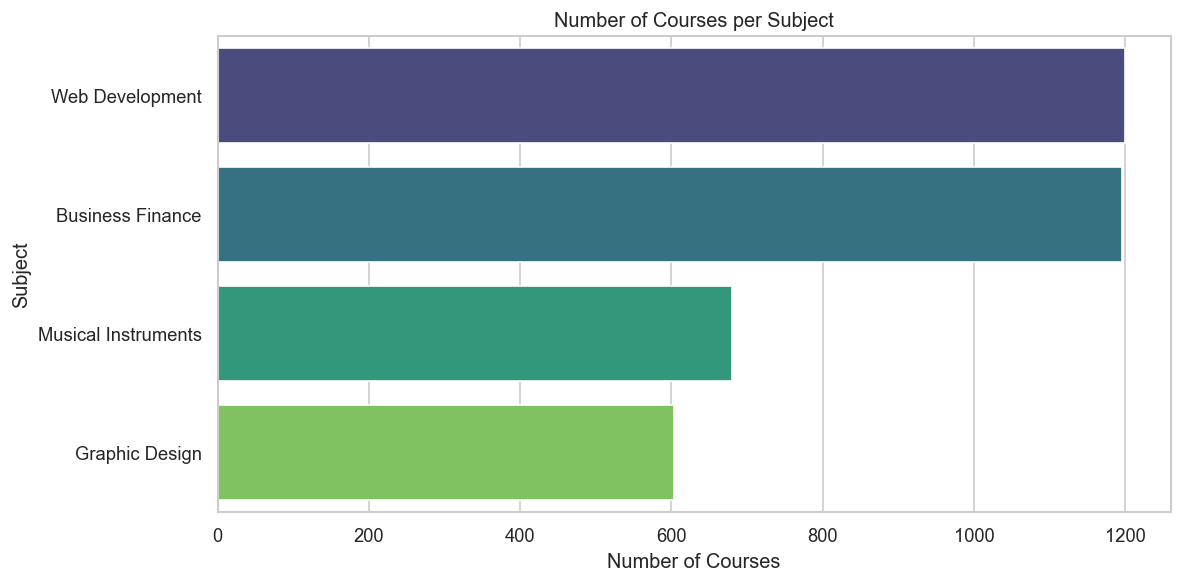

In [9]:
plt.figure(figsize=(10, 5))
subject_counts = df["subject"].value_counts()
sns.barplot(x=subject_counts.values, y=subject_counts.index, hue=subject_counts.index, palette="viridis", legend=False)
plt.title("Number of Courses per Subject")
plt.xlabel("Number of Courses")
plt.ylabel("Subject")
plt.tight_layout()
plt.show()

This chart correctly uses the `subject` column. The dataset is concentrated in Web Development and Business Finance, followed by Musical Instruments and Graphic Design, so category balance should be considered when evaluating recommendations.


### Distribution of Subscribers

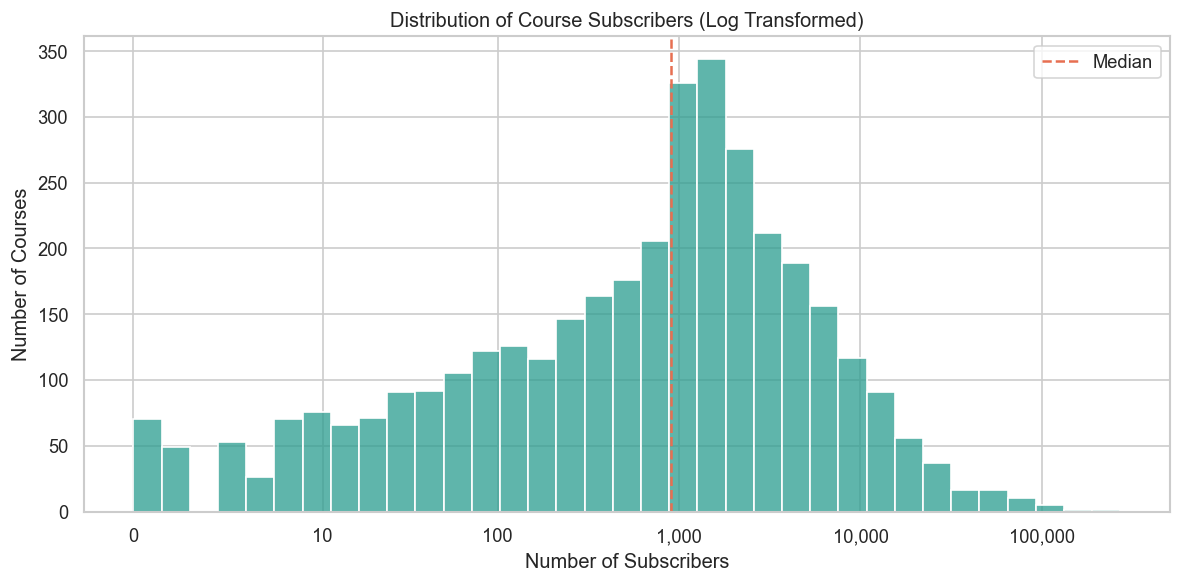

In [10]:
subscriber_counts_log = np.log10(df["num_subscribers"] + 1)
median_subscribers_log = np.log10(df["num_subscribers"].median() + 1)

plt.figure(figsize=(10, 5))
sns.histplot(subscriber_counts_log, bins=35, kde=False, color="#2a9d8f")
plt.axvline(median_subscribers_log, color="#e76f51", linestyle="--", label="Median")
plt.title("Distribution of Course Subscribers (Log Transformed)")
plt.xlabel("Number of Subscribers")
plt.ylabel("Number of Courses")
subscriber_ticks = [0, 10, 100, 1_000, 10_000, 100_000]
plt.xticks(
    np.log10(np.array(subscriber_ticks) + 1),
    [f"{tick:,}" for tick in subscriber_ticks]
)
plt.legend()
plt.tight_layout()
plt.show()

This chart uses the `num_subscribers` column with a log transformation. This is more meaningful than a raw histogram because course popularity is highly right-skewed: most courses have relatively few subscribers, while a small number of courses attract very large audiences.

### Distribution of Course Levels

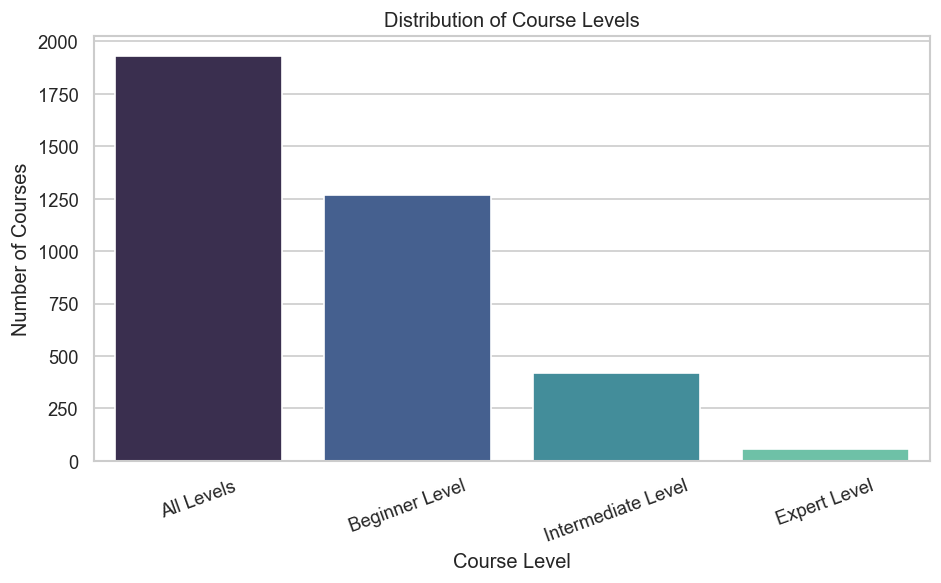

In [11]:
plt.figure(figsize=(8, 5))
level_order = ["All Levels", "Beginner Level", "Intermediate Level", "Expert Level"]
level_counts = df["level"].value_counts().reindex(level_order)
sns.barplot(x=level_counts.index, y=level_counts.values, hue=level_counts.index, palette="mako", legend=False)
plt.title("Distribution of Course Levels")
plt.xlabel("Course Level")
plt.ylabel("Number of Courses")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


This chart correctly uses the `level` column. Most courses are marked as All Levels or Beginner Level, while Expert Level courses are rare, so level-based filtering may produce fewer options for advanced learners.


## 9. Final Conclusions

The dataset is clean enough for a university recommender systems project, but preprocessing should remove the 6 duplicate course records and review the single zero-duration/zero-lecture record.

The most useful features for recommendation are `course_title`, `subject`, `level`, `price`, `is_paid`, `num_subscribers`, `num_reviews`, `num_lectures`, and `content_duration`. These columns describe course topics, categories, difficulty, cost, popularity, engagement, and workload.

A content-based recommendation approach is suitable for this dataset because the available data describes the courses themselves. Courses can be compared using titles, subjects, levels, prices, and durations; popularity indicators such as subscribers and reviews can then be used for ranking or filtering.

Collaborative filtering is not suitable for this dataset in its current form because there are no individual user IDs, user ratings, purchase histories, or user-course interaction records.

No recommendation algorithms are implemented in this notebook. The goal here is only to understand the dataset before moving to preprocessing and modeling.
